Here is the excerpt from the paper that tells us the values of alpha and beta:


We present our ZTF Hubble diagram for the 2629 non-peculiar SNe~Ia that pass our quality cuts in Figure~6. These SNe~Ia have been standardized using the methodology detailed in Ginolin et~al.~(2024), given the SALT2 stretch and color parameters and host local environmental properties (for example, Sullivan et~al.~2010; Rigault et~al.~2020). Following that paper, we adopt the nuisance parameter values $\alpha = -0.16$, $\beta = 3.05$, and $\gamma = 0.145~\mathrm{mag}$ (local-color step).


The standardized distance modulus for each Type~Ia supernova is computed using the Tripp (1998) relation:

The observed distance modulus in the SALT2 framework is given by: 

$
\mu_{\mathrm{obs}} = -2.5 \log_{10}(x_0) + \alpha x_1 - \beta c
$

Link to paper: [doi.org/10.1051/0004-6361/202450943](https://www.aanda.org/articles/aa/full_html/2025/02/aa50943-24/aa50943-24.html)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.optimize import minimize_scalar
from astropy.stats import sigma_clip

# Lets First Do Some Host Galaxy Quality Cuts on Our Sample #

Judging from the following 

In [17]:
# Read the following file:

df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop.csv")
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 65 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    539 non-null    float64
 1   ztfname                           539 non-null    object 
 2   ZTF_redshift                      539 non-null    float64
 3   ZTF_redshift_err                  539 non-null    float64
 4   ZTF_source                        539 non-null    object 
 5   ZTF_t0                            539 non-null    float64
 6   ZTF_x0                            539 non-null    float64
 7   ZTF_x1                            539 non-null    float64
 8   ZTF_c                             539 non-null    float64
 9   ZTF_t0_err                        539 non-null    float64
 10  ZTF_x0_err                        539 non-null    float64
 11  ZTF_x1_err                        539 non-null    float64
 12  ZTF_c_er

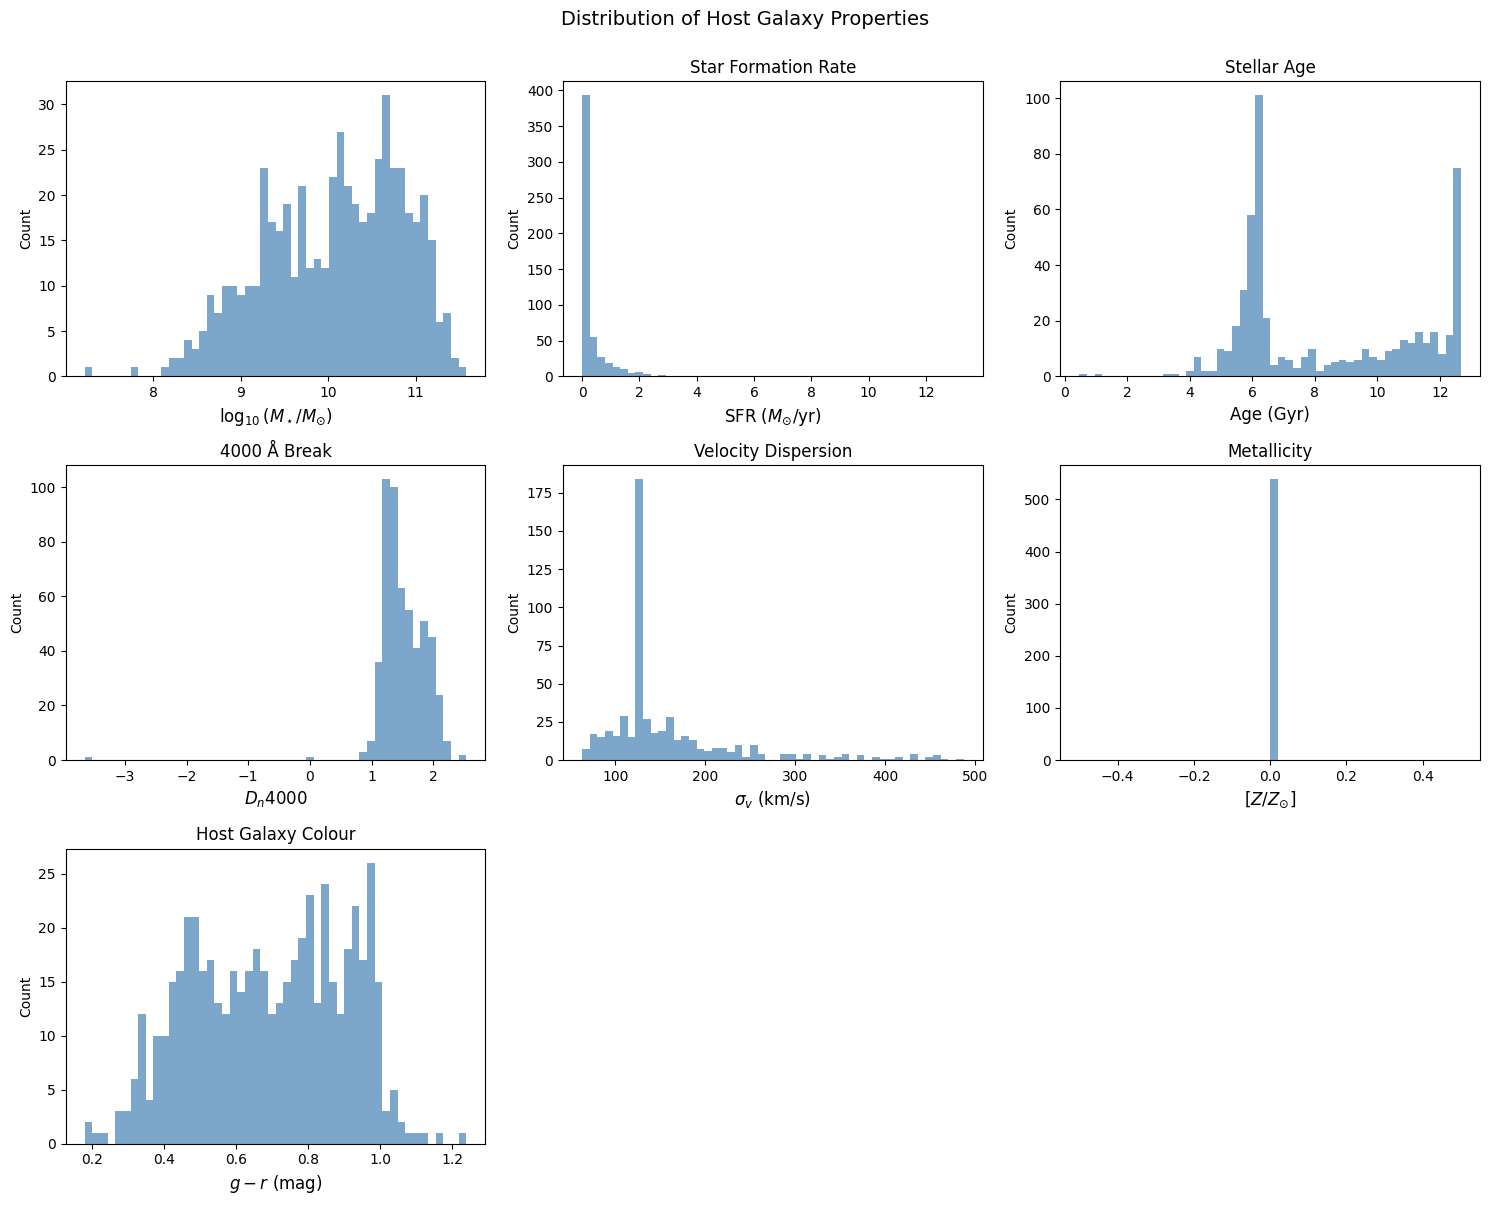

In [18]:
df["DESI_FASTSPEC_g_minus_r"] = df["DESI_FASTSPEC_ABSMAG01_SDSS_G"] - df["DESI_FASTSPEC_ABSMAG01_SDSS_R"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

ax = axes[0, 0]
ax.hist(df["DESI_FASTSPEC_LOGMSTAR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$", fontsize=12)
ax.set_ylabel("Count")

ax = axes[0, 1]
ax.hist(df["DESI_FASTSPEC_SFR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"SFR $(M_{\odot}/\mathrm{yr})$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Star Formation Rate")

ax = axes[0, 2]
ax.hist(df["DESI_FASTSPEC_AGE"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"Age (Gyr)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Stellar Age")

ax = axes[1, 0]
ax.hist(df["DESI_FASTSPEC_DN4000"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$D_n4000$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("4000 Å Break")

ax = axes[1, 1]
ax.hist(df["DESI_FASTSPEC_VDISP"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\sigma_v$ (km/s)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Velocity Dispersion")

ax = axes[1, 2]
ax.hist(df["DESI_FASTSPEC_ZZSUN"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$[Z/Z_{\odot}]$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Metallicity")

ax = axes[2, 0]
ax.hist(df["DESI_FASTSPEC_g_minus_r"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$g - r$ (mag)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Host Galaxy Colour")

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

fig.suptitle("Distribution of Host Galaxy Properties", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Now Lets Get some Quality Cuts Defined and See What the Final Histograms Looks Like #

In [19]:
print(f"Before cuts: {len(df)}")

mask_sfr = df["DESI_FASTSPEC_SFR"] <= 2.5
print(f"SFR <= 2.5:    {mask_sfr.sum()} keep, {(~mask_sfr).sum()} dropped")
df = df[mask_sfr].reset_index(drop=True)

mask_dn4000 = df["DESI_FASTSPEC_DN4000"] >= 0.5
print(f"DN4000 >= 0.5: {mask_dn4000.sum()} keep, {(~mask_dn4000).sum()} dropped")
df = df[mask_dn4000].reset_index(drop=True)

mask_age = df["DESI_FASTSPEC_AGE"] >= 2
print(f"AGE >= 2 Gyr:  {mask_age.sum()} keep, {(~mask_age).sum()} dropped")
df = df[mask_age].reset_index(drop=True)

print(f"After all cuts: {len(df)}")

Before cuts: 540
SFR <= 2.5:    531 keep, 9 dropped
DN4000 >= 0.5: 529 keep, 2 dropped
AGE >= 2 Gyr:  527 keep, 2 dropped
After all cuts: 527


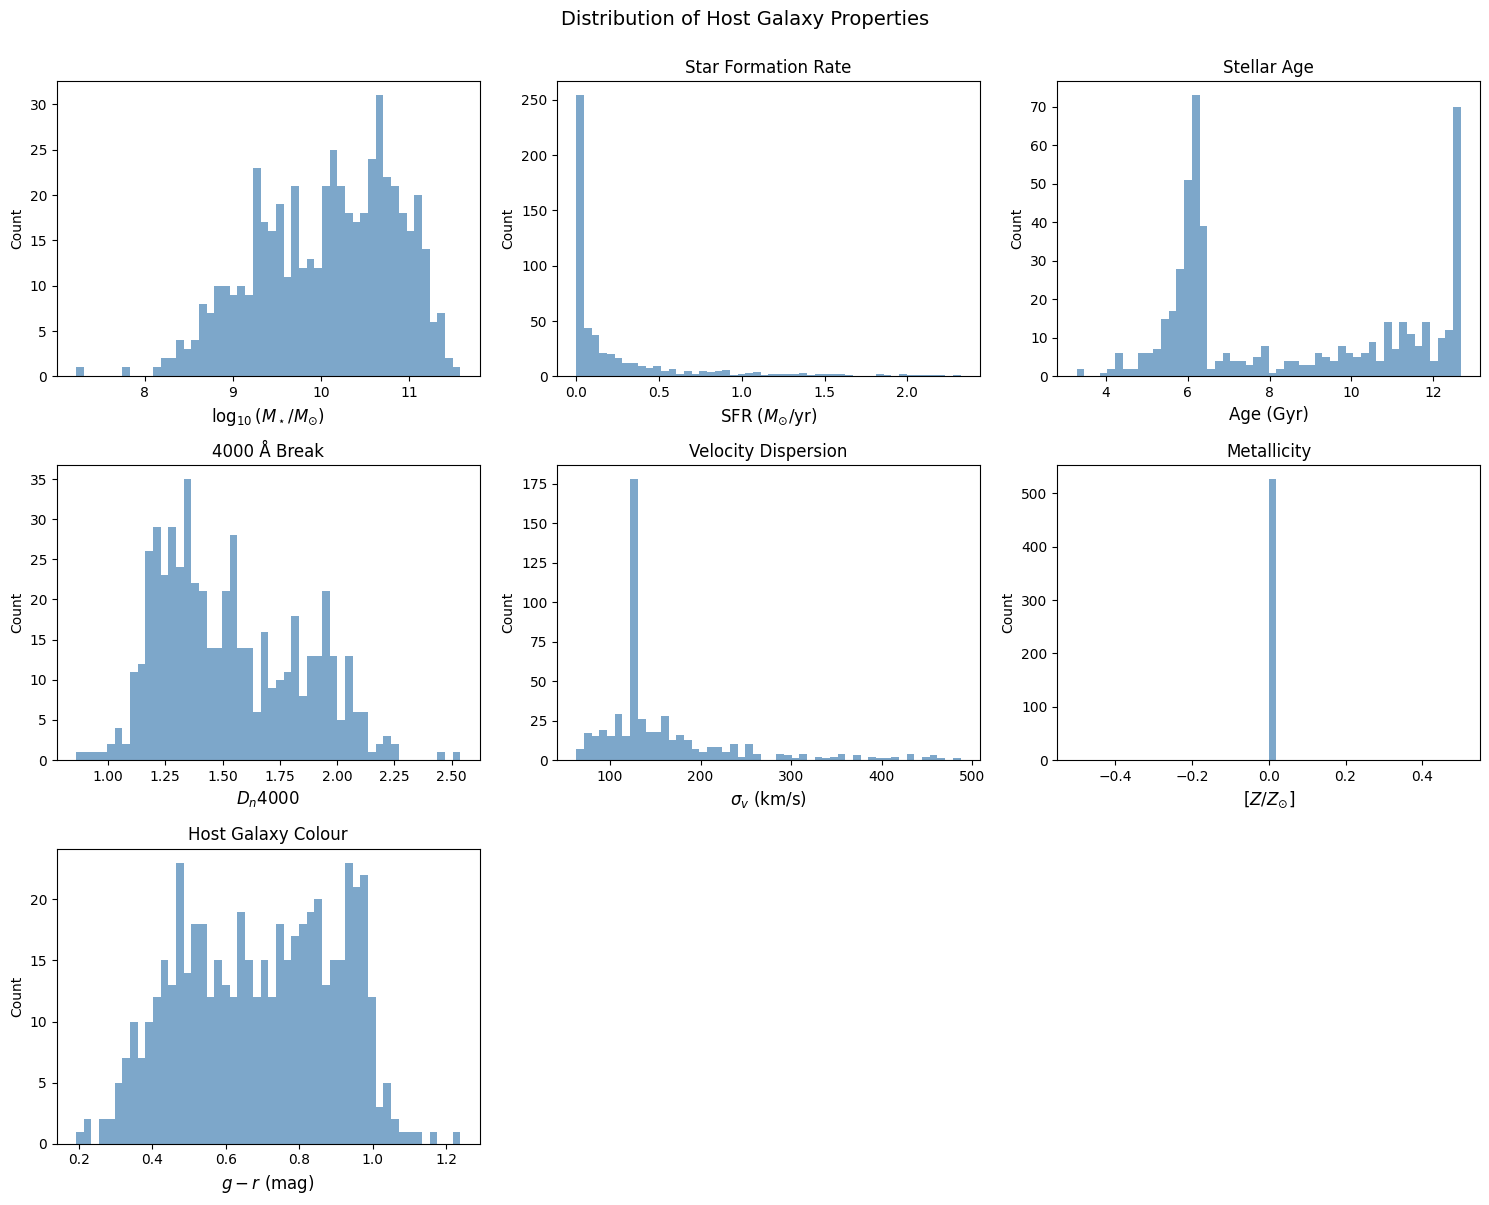

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

ax = axes[0, 0]
ax.hist(df["DESI_FASTSPEC_LOGMSTAR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$", fontsize=12)
ax.set_ylabel("Count")

ax = axes[0, 1]
ax.hist(df["DESI_FASTSPEC_SFR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"SFR $(M_{\odot}/\mathrm{yr})$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Star Formation Rate")

ax = axes[0, 2]
ax.hist(df["DESI_FASTSPEC_AGE"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"Age (Gyr)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Stellar Age")

ax = axes[1, 0]
ax.hist(df["DESI_FASTSPEC_DN4000"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$D_n4000$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("4000 Å Break")

ax = axes[1, 1]
ax.hist(df["DESI_FASTSPEC_VDISP"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\sigma_v$ (km/s)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Velocity Dispersion")

ax = axes[1, 2]
ax.hist(df["DESI_FASTSPEC_ZZSUN"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$[Z/Z_{\odot}]$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Metallicity")

ax = axes[2, 0]
ax.hist(df["DESI_FASTSPEC_g_minus_r"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$g - r$ (mag)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Host Galaxy Colour")

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

fig.suptitle("Distribution of Host Galaxy Properties", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [21]:
# Define the following global parameters:

alpha = 0.161
beta  = 3.05

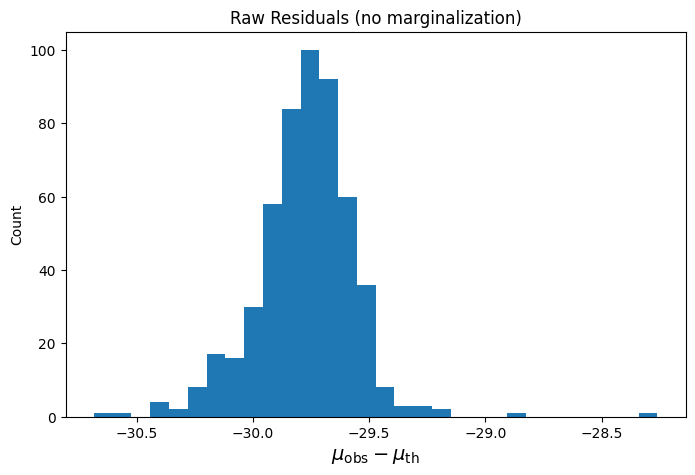

In [22]:
# Calculate the observed distance modulus for each supernova in the dataset: (not mass step corrected by design):
df["ZTF_mu_obs"] = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"]

# Define the following cosmology:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Evaluate the cosmology at the ZTF reported redshift. We are using the ZTF redshift instead of DESI
# b/c we're propagating the ZTF uncertainty and we want to keep everything in the same data set. 

mu_th = cosmo.distmod(df["ZTF_redshift"]).value
raw_residuals = df["ZTF_mu_obs"] - mu_th

plt.figure(figsize=(8, 5))
plt.hist(raw_residuals, bins=30)
plt.xlabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}}$", fontsize=14)
plt.ylabel("Count")
plt.title("Raw Residuals (no marginalization)")
plt.show()

# Now lets do the error Propagation from the SALT 2 Model Error #

General Form of the Error Propagation Formula for $y = f(x_1, x_2, \ldots, x_n)$

$
\sigma_y^2 =
\sum_{i=1}^{n}
\left(
\frac{\partial f}{\partial x_i}
\right)^2
\sigma_{x_i}^2
+
\sum_{i \ne j}
2\,
\frac{\partial f}{\partial x_i}
\frac{\partial f}{\partial x_j}
\mathrm{Cov}(x_i, x_j).
$

Using the standard error propagation formula:

$$
\sigma_{\mu,\text{obs}} = \sqrt{
\left(\frac{\partial \mu}{\partial x_0}\right)^2 \sigma_{x_0}^2
+\left(\frac{\partial \mu}{\partial x_1}\right)^2 \sigma_{x_1}^2
+\left(\frac{\partial \mu}{\partial c}\right)^2 \sigma_c^2
+ 2\left(\frac{\partial \mu}{\partial x_0}\frac{\partial \mu}{\partial x_1}\right)\mathrm{Cov}(x_0,x_1)
+ 2\left(\frac{\partial \mu}{\partial x_0}\frac{\partial \mu}{\partial c}\right)\mathrm{Cov}(x_0,c)
+ 2\left(\frac{\partial \mu}{\partial x_1}\frac{\partial \mu}{\partial c}\right)\mathrm{Cov}(x_1,c)
}
$$


where:

$
\frac{\partial\mu}{\partial x_0} = \frac{-2.5}{x_0\ln 10}
$

$
\frac{\partial\mu}{\partial x_1} = \alpha
$

$
\frac{\partial\mu}{\partial c} = -\beta
$


Reference: Bevington Ch. 3 Summary



In [23]:
LN10 = np.log(10)

# Partial derivatives of mu_obs w.r.t. SALT2 parameters

dmu_dx0 = -2.5 / (df["ZTF_x0"] * LN10)
dmu_dx1 = alpha
dmu_dc  = -beta

df["ZTF_sigma_mu"] = np.sqrt(
    dmu_dx0**2 * df["ZTF_x0_err"]**2
  + dmu_dx1**2 * df["ZTF_x1_err"]**2
  + dmu_dc**2  * df["ZTF_c_err"]**2
  + 2 * dmu_dx0 * dmu_dx1 * df["ZTF_cov_x0_x1"]
  + 2 * dmu_dx0 * dmu_dc  * df["ZTF_cov_x0_c"]
  + 2 * dmu_dx1 * dmu_dc  * df["ZTF_cov_x1_c"]
)


# Now Lets Do $\chi^2$ Minnimization #

Note we start with a redshift (i.e. volume) limited sample of z < 0.06 as was done in prior work with: 

ZTF SN Ia DR2: Colour standardisation of type Ia supernovae and its dependence on the environment M. Ginolin

This is done to get rid of biases that we end up seeing at higher redshifts. Maily malmquist bias. 

We will define our volume limiting via the ZTF repoprted redshift by the way to keep in line with Ginolin et al

We find $\mathscr{M}$ by minimizing:

$\chi^2(\mathscr{M}) = \sum_i \frac{\left(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i} - \mathscr{M}\right)^2}{\sigma_{\mu,i}^2}$


$\mathscr{M}$ is the only free parameter. It absorbs the degenerate combination of $M_B$ and $H_0$. 

Changing $\mathscr{M}$ shifts all $\mu_{\mathrm{obs}}$ by the same constant — the optimizer finds the value that places

 the data on the theory curve (i.e. minimizes the weighted sum of squared residuals).

In [24]:
# Create a new data frame where we only keep SNe with z < 0.06 to construct a volume-limited sample. 
# Note this is done to our data and our sample. We are not using the Ginolin data but rather following in their
# footsteps. 

df_vlim = df[df["ZTF_redshift"] < 0.06].copy()

print(f"Volume-limited sample has: {len(df_vlim)} SNe (z < 0.06)")

# Need to put .value here or it will throw an error. 
mu_th_vlim = cosmo.distmod(df_vlim["ZTF_redshift"]).value

# Construct the chi2 function to minimize. 

def chi2(script_M):
    mu_obs = -2.5 * np.log10(df_vlim["ZTF_x0"]) + alpha * df_vlim["ZTF_x1"] - beta * df_vlim["ZTF_c"] - script_M
    residuals = mu_obs - mu_th_vlim
    return np.sum(residuals**2 / df_vlim["ZTF_sigma_mu"]**2)

# Note minimize_scalare takes whatever function I give it and
# minimizes it over that function's single input argument. 
result_vlim = minimize_scalar(chi2)
print("\n")
print(result_vlim)

Volume-limited sample has: 196 SNe (z < 0.06)


 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: 1573.0487388511908
       x: -29.759687005648967
     nit: 4
    nfev: 9


# Now that We Minimized $\chi^2$ for the Volume Limited Sample of Our Data Lets find the $\chi^2$/dof of the volume limited sample #

In [25]:
# Best-fit nuisance parameter from chi2 minimization
scriptM_vlim = result_vlim.x

# chi2 and reduced chi2 for the volume-limited fit
chi2_min_vlim = result_vlim.fun
n_data = len(df_vlim)
n_params = 1  # only script_M is fit
dof_vlim = n_data - n_params
chi2_per_dof_vlim = chi2_min_vlim / dof_vlim

print(f"Best-fit script_M: {scriptM_vlim:.6f}")
print(f"chi2_min: {chi2_min_vlim:.3f}")
print(f"dof: {dof_vlim}")
print(f"chi2/dof: {chi2_per_dof_vlim:.3f}")

Best-fit script_M: -29.759687
chi2_min: 1573.049
dof: 195
chi2/dof: 8.067


# Now that We Minimized the Negative Log Likelihood for the Volume Limited Sample We are Ready to compute the Residuals #

/var/folders/71/hv72gkrs7g59ty6664549kjr0000gr/T/ipykernel_33425/2337485234.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(sim_z, mu_th_plot, "r-", label="Theoretical Distance Modulus", color = "orange", linewidth = 5)


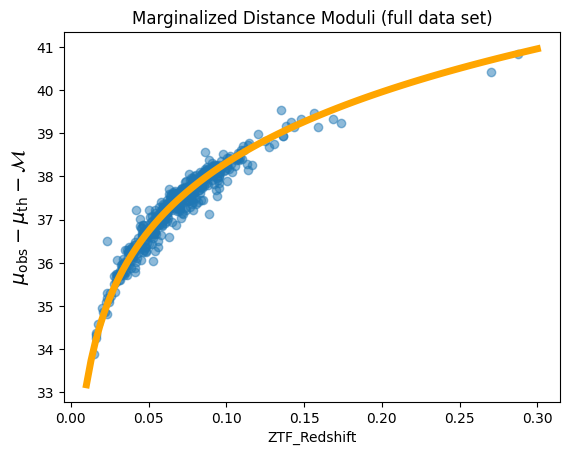

In [26]:
# Note we are applying this script-M to the full data set.
# We are just borrowing scriptM_vlim from the volume limited sample.
# "ZTF_mu_obs" 
marginalized_distance_modulus = df["ZTF_mu_obs"] - scriptM_vlim

# Data necessary froom the Theory Plot
sim_z = np.linspace(0.01, 0.3, 100)
mu_th_plot = cosmo.distmod(sim_z).value


plt.plot(df["ZTF_redshift"], marginalized_distance_modulus, "o", alpha=0.5)
plt.plot(sim_z, mu_th_plot, "r-", label="Theoretical Distance Modulus", color = "orange", linewidth = 5)
plt.xlabel("ZTF_Redshift")
plt.ylabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}} - \mathcal{M}$", fontsize=14)
plt.title("Marginalized Distance Moduli (full data set)")
plt.show()

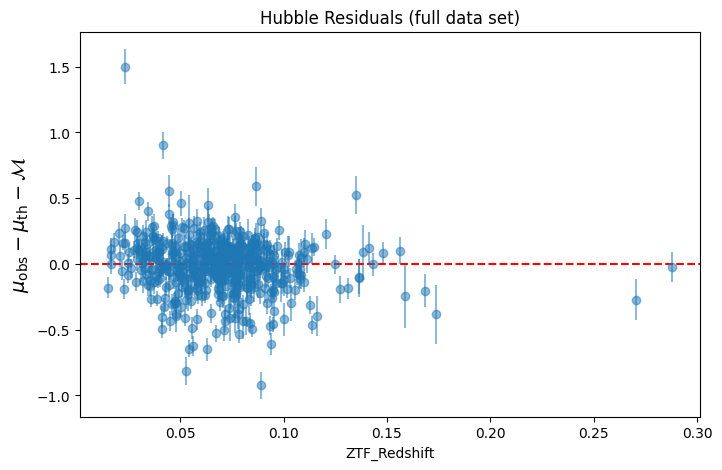

In [27]:
df["residuals"] = df["ZTF_mu_obs"] - cosmo.distmod(df["ZTF_redshift"]).value - scriptM_vlim
plt.figure(figsize=(8, 5))
plt.errorbar(df["ZTF_redshift"], df["residuals"], yerr=df["ZTF_sigma_mu"], fmt="o", alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("ZTF_Redshift")
plt.ylabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}} - \mathcal{M}$", fontsize=14)
plt.title("Hubble Residuals (full data set)")
plt.show()

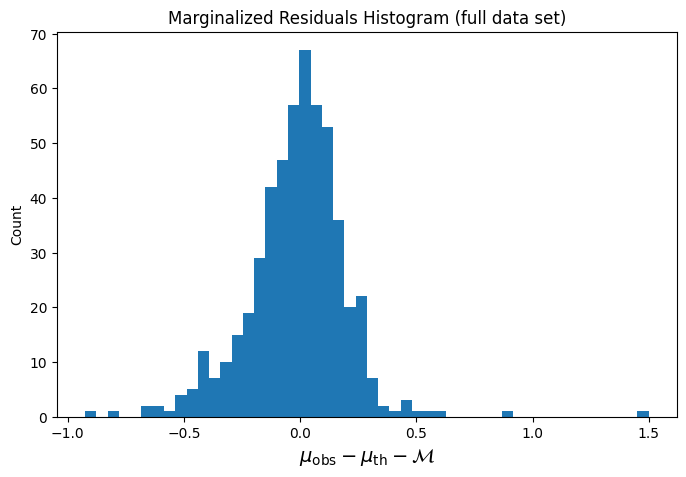

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(df["residuals"], bins=50)
plt.xlabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}} - \mathcal{M}$", fontsize=14)
plt.ylabel("Count")
plt.title("Marginalized Residuals Histogram (full data set)")
plt.show()


# Now We Will Sigma Clip the Hubble Residuals #

Sigma clipping is a common method for outlier rejection. 

By sigma clipping, we say "anything more than 3 standard deviations from the median is probably not part of the real distribution I care about."




527 SNe before sigma clip
521 SNe after 3σ clipping on Δμ


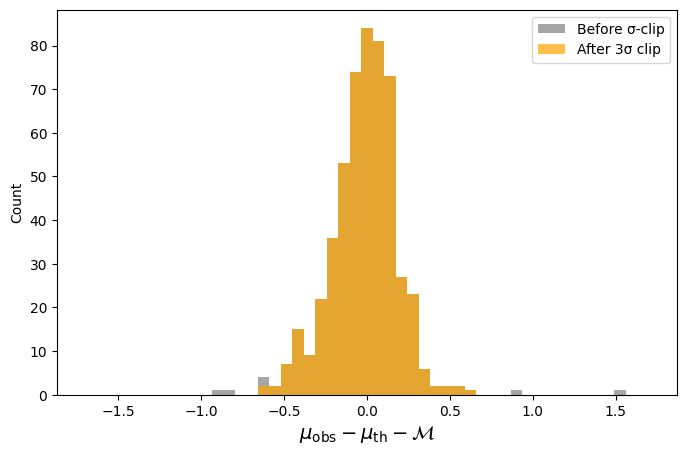

In [29]:
# 3-sigma clip, single iteration
# returns a masked array where the outliers are 
# masked true and all other data points ar emasked false.
# NOTE: we sigma clip one, if we wanted to rebalance the median
# and clip again. Then 
unclipped_residuals = df["residuals"]
clip = sigma_clip(df["residuals"], sigma=3, maxiters=1)
mask_keep = ~clip.mask # retain all other points esides outliers.

print(f"{len(df)} SNe before sigma clip")
df = df.loc[mask_keep]
print(f"{len(df)} SNe after 3σ clipping on Δμ")

bins = np.linspace(-1.7, 1.7, 50)
plt.figure(figsize=(8, 5))
plt.hist(unclipped_residuals, bins=bins, label="Before σ-clip", color="gray", alpha=0.7)
plt.hist(df["residuals"], bins=bins, label="After 3σ clip", color="orange", alpha=0.7)
plt.xlabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}} - \mathcal{M}$", fontsize=14)
plt.ylabel("Count")
plt.legend()
plt.show()

In [30]:
df.to_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_chi2_only.csv", index=False)